# Neural networks: a systematic family of flexible models

Notebook 3 surfaced the central practical question of model fitting: **what function family should we pick?** A polynomial of degree 8? Degree 15? An exponential? A sum of sines? The data doesn't come with a label telling us. Choose something too rigid and the model underfits; choose something too flexible and it overfits. Picking *well* is the real challenge — and it's one we never fully escape.

**Neural networks are the answer the field converged on.** They give us a single, recipe-driven family of functions that:

- is **flexible enough** to approximate essentially any reasonable function (the universal approximation theorem),
- is built from **composable** building blocks, so we can dial capacity up or down without rewriting anything,
- is **trainable** with the gradient descent we've already learned, scaling from a handful of parameters to trillions,
- and has **proven itself in practice** at every size — from the toy networks in this notebook to the language models people use every day.

The next three sections build the three smallest possible neural networks *by hand* and let you drive their parameters with sliders. We're not training yet — we're getting a feel for what each shape of network can and can't express.

## A single neuron — the atomic building block

The whole field is built on top of one tiny ingredient: the **neuron**. It takes one or more inputs, multiplies each by a learnable **weight**, sums them, adds a **bias**, and pushes the result through a non-linear **activation function** to produce a single output.

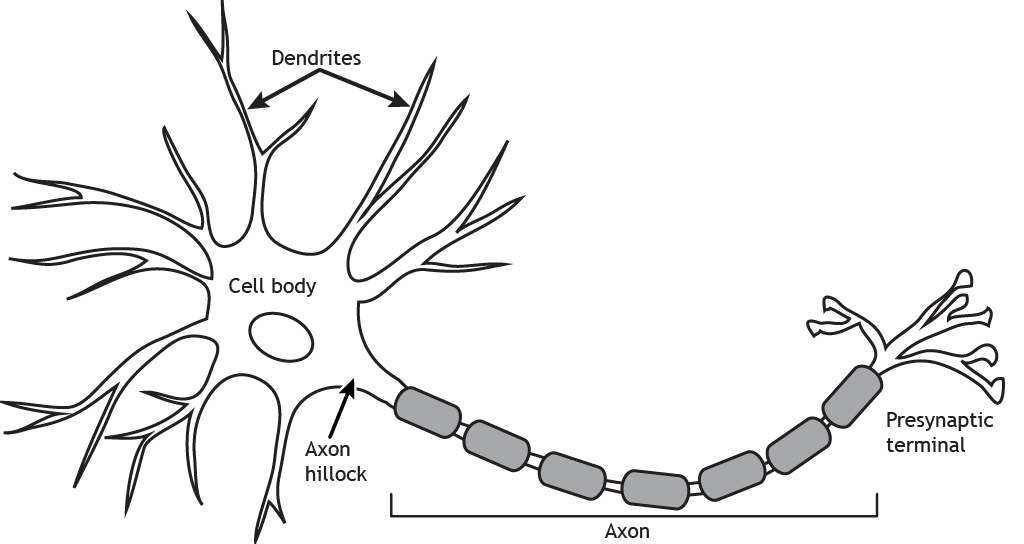

In our 1-D setting that boils down to:

$$\text{neuron}(x) \;=\; \sigma\big(w \cdot x + b\big)$$

- $w$ and $b$ are the **learnable parameters**.
- $\sigma$ is the **activation**. We use **ReLU**, $\sigma(z) = \max(0, z)$, throughout this notebook.
- The non-linearity is the whole point — without it, stacking many neurons would collapse algebraically into a single linear model and we'd gain nothing.

Every network in this notebook (and every model in nanoGPT) is built by wiring up many copies of this same atom.

## Three architectures we'll build

We'll wire neurons together three ways and drive each one by hand:

1. **1 neuron, 1 layer** — the smallest possible network, just the atom on its own.
2. **1 hidden layer, 2 neurons** — *width*: two neurons in parallel, combined by a linear output layer.
3. **2-layer MLP `[2, 2, 1]`** — *depth + width*: a second hidden layer that recombines the first layer's outputs into new features.

Same target dataset for all three. The contrast between what each fit can and can't capture is the lesson — it makes the role of **width** versus **depth** visible.

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
import ipywidgets as widgets
from IPython.display import display
pio.renderers.default = "notebook"

def relu(x):
    return np.maximum(0.0, x)

## The target

For this notebook we'll fit a **double bump** — two Gaussian peaks at $x = -1.5$ and $x = +1.5$, plus a small baseline and additive noise. Two bumps separate width from depth more cleanly than one:

- A single ReLU neuron makes only one kink — hopeless for either bump.
- Two ReLUs combined linearly can build *one* tent — so a single hidden layer of width 2 can only fit one of the two bumps.
- To fit *both* bumps at once, we need either more width (4+ neurons in a single hidden layer) or **depth combined with width**: a second hidden layer that recombines the first layer's outputs into tents at arbitrary locations.

The same target therefore stresses A, B, and C very differently — and exposes where depth genuinely matters.

In [ ]:
rng = np.random.default_rng(seed=1)

n_samples = 80
x_np = np.linspace(-3.5, 3.5, n_samples)
y_clean = (0.8 * np.exp(-((x_np + 1.5) ** 2) / 0.5)
           + 1.0 * np.exp(-((x_np - 1.5) ** 2) / 0.5) + 0.2)
y_np = y_clean + rng.normal(0.0, 0.06, size=n_samples)

x_dense = np.linspace(x_np.min(), x_np.max(), 400)
y_clean_dense = (0.8 * np.exp(-((x_dense + 1.5) ** 2) / 0.5)
                 + 1.0 * np.exp(-((x_dense - 1.5) ** 2) / 0.5) + 0.2)

fig = go.Figure()
fig.add_trace(go.Scatter(x=x_np, y=y_np, mode="markers", name="data",
                         marker=dict(size=6, opacity=0.8)))
fig.add_trace(go.Scatter(x=x_dense, y=y_clean_dense, mode="lines",
                         name="true double bump",
                         line=dict(color="crimson", width=2),
                         visible="legendonly"))
fig.update_layout(title="Target dataset: a noisy double bump",
                  xaxis_title="x", yaxis_title="y",
                  template="plotly_white", width=750, height=420)
fig.show()

### Plumbing: an interactive-fit helper

This is just the slider widget we've used before, packaged into a function so each architecture below can call it with a one-liner. Skim and move on — the interesting stuff is the model functions in the cells after this.

In [ ]:
def _residual_segments(x, y, y_pred):
    n = len(x)
    rx = np.empty(3 * n, dtype=object)
    ry = np.empty(3 * n, dtype=object)
    rx[0::3] = x;       ry[0::3] = y
    rx[1::3] = x;       ry[1::3] = y_pred
    rx[2::3] = None;    ry[2::3] = None
    return rx, ry


def interactive_fit(model_fn, param_specs, title,
                    x_data=x_np, y_data=y_np, x_grid=x_dense):
    """
    model_fn(x, *params) -> y_pred
    param_specs: iterable of (name, init, vmin, vmax, step) tuples — one per parameter
    """
    # Lock the axis ranges so moving the sliders never rescales the view —
    # otherwise the model curve "moves" because the y-axis just shifts under it.
    x_lo, x_hi = float(x_grid.min()), float(x_grid.max())
    y_lo = float(min(y_data.min(), 0.0)) - 0.5
    y_hi = float(y_data.max()) + 0.7

    fig = go.FigureWidget()
    fig.add_trace(go.Scatter(x=[], y=[], mode="lines", name="residuals",
                             line=dict(color="rgba(120,120,120,0.5)", width=1),
                             hoverinfo="skip"))
    fig.add_trace(go.Scatter(x=x_data, y=y_data, mode="markers", name="data",
                             marker=dict(size=6, opacity=0.85)))
    fig.add_trace(go.Scatter(x=x_grid, y=np.zeros_like(x_grid),
                             mode="lines", name="model",
                             line=dict(color="orange", width=3)))
    fig.update_layout(
        title=f"{title} | MSE: —",
        xaxis=dict(title="x", range=[x_lo, x_hi], autorange=False),
        yaxis=dict(title="y", range=[y_lo, y_hi], autorange=False),
        template="plotly_white",
        autosize=True, height=420,
        margin=dict(l=20, r=20, t=50, b=20),
    )

    sliders = [
        widgets.FloatSlider(value=init, min=vmin, max=vmax, step=step,
                            description=name, continuous_update=True,
                            readout_format=".2f",
                            layout=widgets.Layout(width="48%"))
        for (name, init, vmin, vmax, step) in param_specs
    ]

    def rerun(*_):
        params = [s.value for s in sliders]
        y_pred = model_fn(x_data, *params)
        y_pred_grid = model_fn(x_grid, *params)
        mse = float(np.mean((y_data - y_pred) ** 2))
        rx, ry = _residual_segments(x_data, y_data, y_pred)
        with fig.batch_update():
            fig.data[0].x = rx; fig.data[0].y = ry
            fig.data[2].y = y_pred_grid
            fig.layout.title.text = f"{title} | MSE: {mse:.4f}"

    for s in sliders:
        s.observe(rerun, names="value")

    rows = [widgets.HBox(sliders[i:i + 2], layout=widgets.Layout(width="100%"))
            for i in range(0, len(sliders), 2)]
    display(widgets.VBox(rows, layout=widgets.Layout(width="100%")), fig)
    rerun()

## Architecture A — 1 neuron, 1 layer

The atomic building block:

$$f(x; w, b) = \text{ReLU}(w \cdot x + b) = \max(0,\ w \cdot x + b)$$

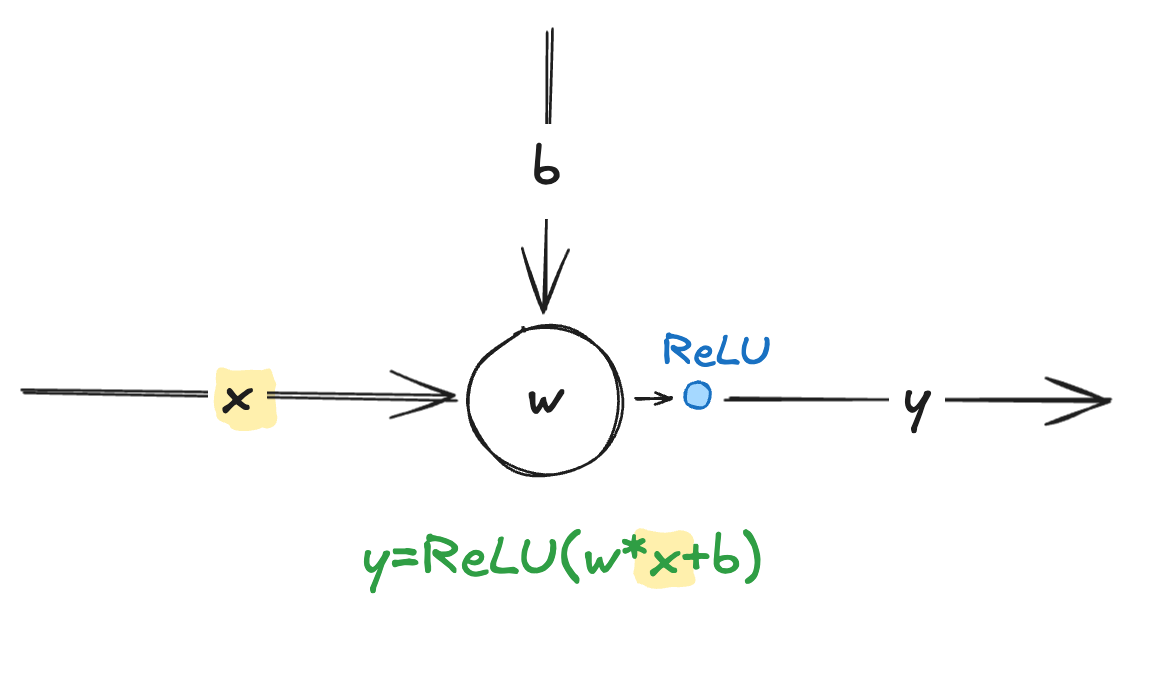

- **$w$** controls the *slope* of the active half — and its sign decides which side is "alive".
- **$b$** controls the *kink position* — the function is zero for $w \cdot x + b < 0$ and linear otherwise. The kink sits at $x = -b/w$.
- The output is always **non-negative**.

Try to fit the bump. You'll find you can't — a single ReLU can ramp up (or ramp down, with $w<0$), but it has no way to go up *and then back down*.

In [ ]:
def model_a(x, w, b):
    return relu(w * x + b)

interactive_fit(
    model_a,
    [("w", 1.0, -5.0, 5.0, 0.05),
     ("b", 0.0, -5.0, 5.0, 0.05)],
    "A: 1 neuron, 1 layer — y = ReLU(w·x + b)",
)

## Architecture B — 1 layer, 2 neurons (width)

Two neurons in parallel, then a linear output layer that combines them:

$$f(x; \mathbf{\theta}) = a_1 \,\text{ReLU}(w_1 x + b_1) + a_2 \,\text{ReLU}(w_2 x + b_2) + c$$

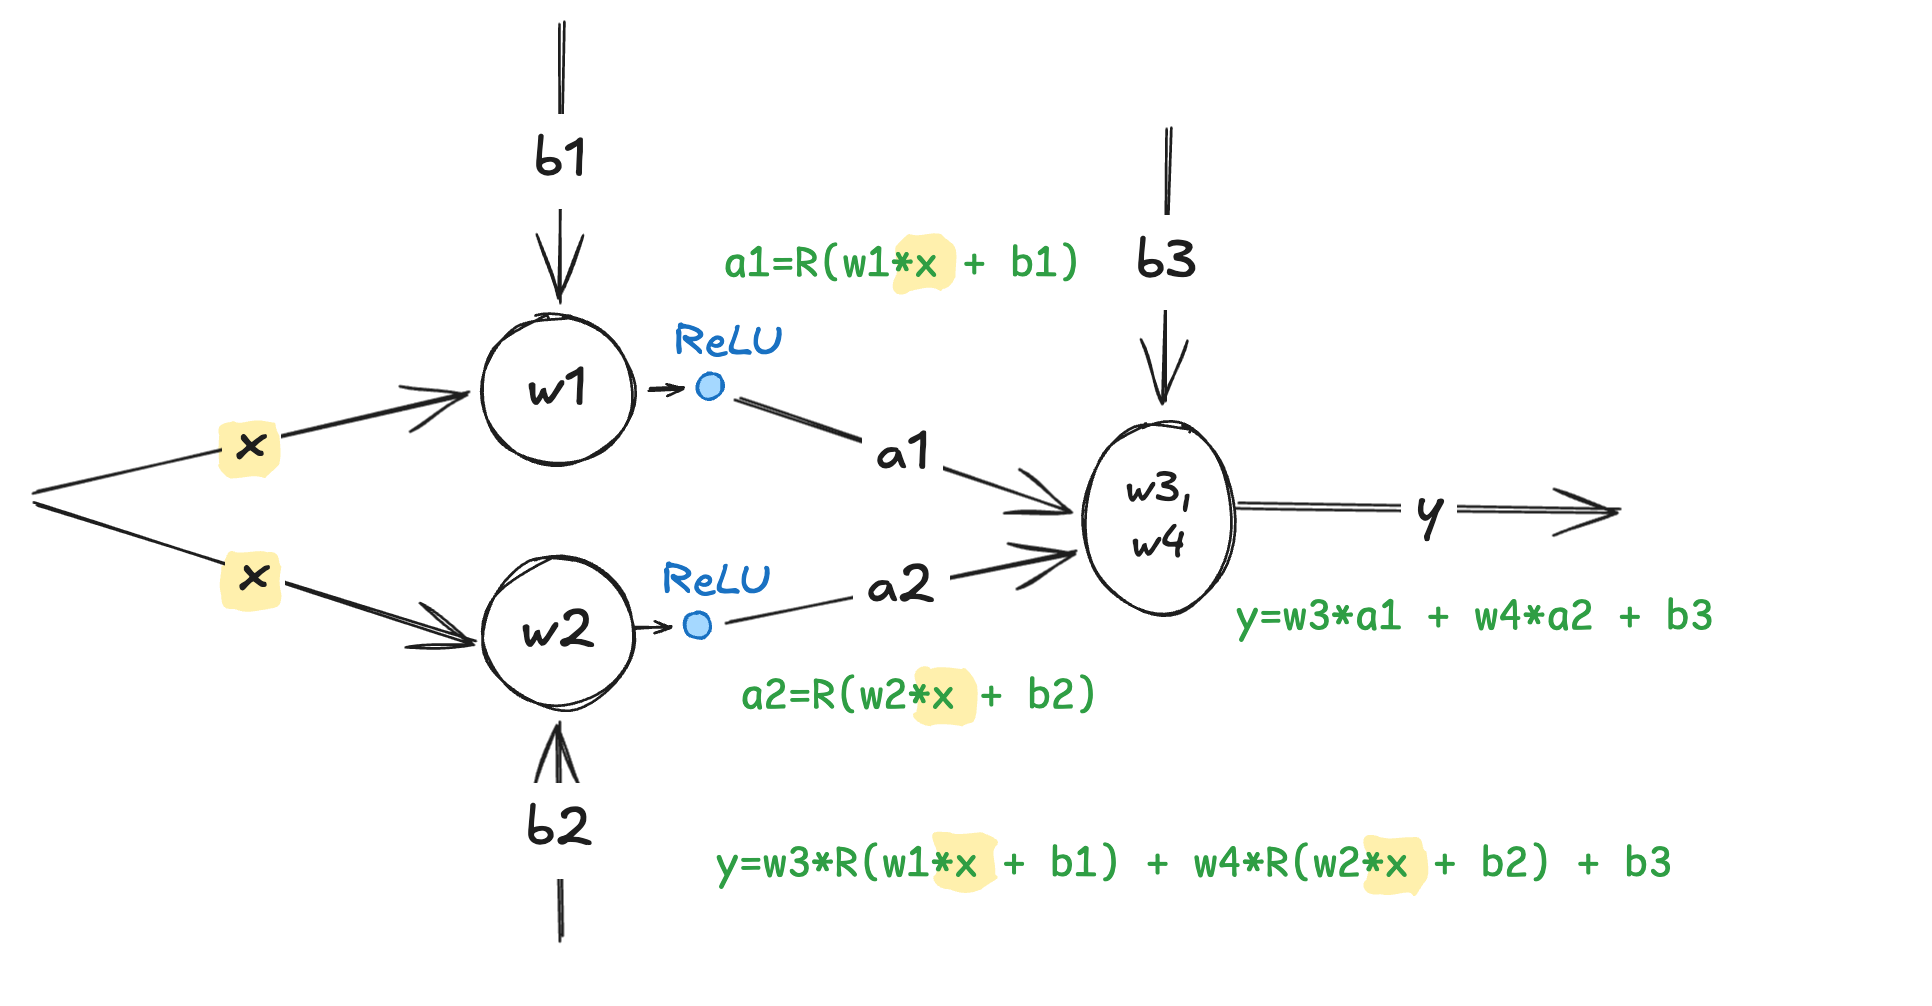

Seven parameters total. Each ReLU contributes a single kink; the combination can have **up to two kinks**. With output weights of opposite signs that's exactly enough for one **tent** — but a tent for *one* bump leaves the other completely unfit.

Initial slider values produce a tent over the right bump at $x = +1.5$. Try sliding the sliders to:

- Move the tent over to the left bump instead. Even with the best fit you can find, the *other* bump is missed by the same amount. This is the visible signature of "two neurons isn't enough capacity".

The takeaway: width-2 single-hidden-layer ReLU nets are limited to one tent, period. To fit two, we need *more* — width 4+ in a single layer, *or* depth combined with width (next).

In [ ]:
def model_b(x, w1, b1, a1, w2, b2, a2, c):
    return a1 * relu(w1 * x + b1) + a2 * relu(w2 * x + b2) + c

interactive_fit(
    model_b,
    [("w1", 1.0, -5.0, 5.0, 0.05),
     ("b1", -0.5, -5.0, 5.0, 0.05),
     ("a1", 1.0, -3.0, 3.0, 0.05),
     ("w2", 1.0, -5.0, 5.0, 0.05),
     ("b2", -1.5, -5.0, 5.0, 0.05),
     ("a2", -2.0, -3.0, 3.0, 0.05),
     ("c", 0.2, -3.0, 3.0, 0.05)],
    "B: 1 layer, 2 neurons — y = a₁·ReLU(w₁x+b₁) + a₂·ReLU(w₂x+b₂) + c",
)

## Architecture C — 2-layer MLP [2, 2, 1] (depth + width)

Now we add a *second* hidden layer with two neurons. Both hidden layers use ReLU; the output layer is linear:

$$
\begin{aligned}
h^{(1)}_i &= \text{ReLU}(w^{(1)}_i x + b^{(1)}_i), \quad i \in \{a, b\} \\
h^{(2)}_j &= \text{ReLU}\Big(w^{(2)}_{j,a} h^{(1)}_a + w^{(2)}_{j,b} h^{(1)}_b + b^{(2)}_j\Big), \quad j \in \{a, b\} \\
f(x) &= v_a h^{(2)}_a + v_b h^{(2)}_b + b_o
\end{aligned}
$$

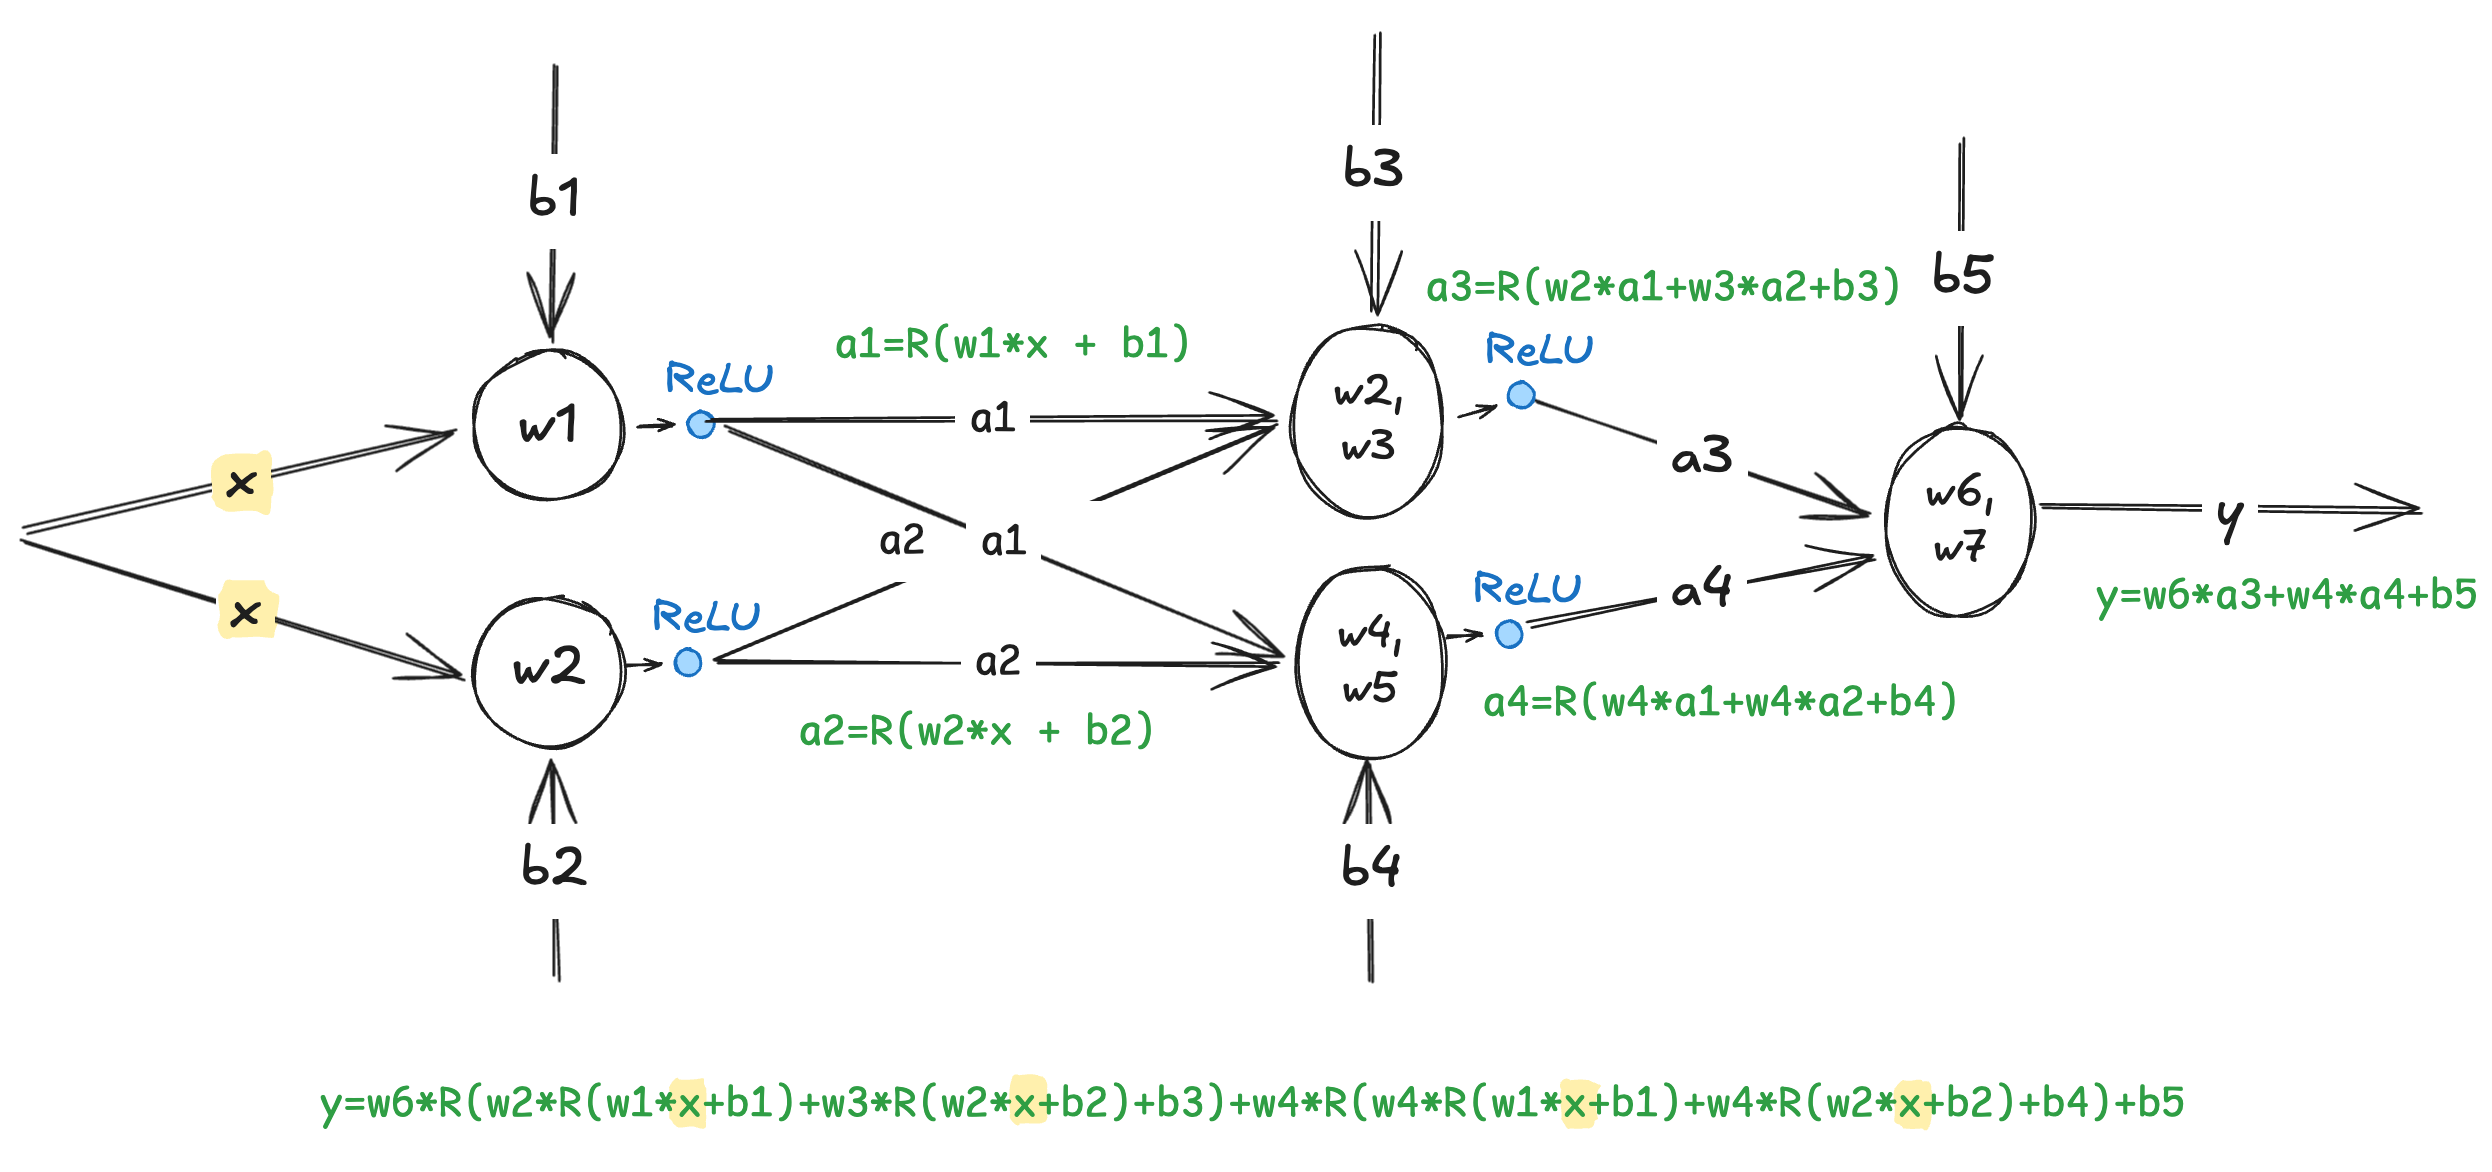

**13 parameters.** Why this is genuinely more expressive than B:

- The first hidden layer still only makes 2 ramps (2 kinks).
- The second hidden layer takes *linear combinations* of those ramps and applies ReLU. Each second-layer neuron can place its own kinks wherever its argument crosses zero — including positions different from the first-layer kinks. With two such neurons, we can build **two independent tents** at arbitrary $x$ locations.
- The output layer scales and combines those tents into the final fit.

The initial slider values are designed so that $h^{(2)}_a$ is a tent at $x = -1.5$ (the left bump) and $h^{(2)}_b$ is a tent at $x = +1.5$ (the right bump). You should see a near-perfect double-bump fit out of the gate.

Try:

- Setting $v_a = 0$. The left bump vanishes — $h^{(2)}_a$ alone was responsible for it.
- Wiggling $b^{(2)}_a$ down toward zero. The left tent collapses (the ReLU stops firing).
- Adjusting $w^{(1)}_a$. The kink that anchors the *left side of both tents* moves — touching one parameter affects both bumps. Welcome to the joys of shared representations.

Hand-tuning 13 parameters is doable but tedious. The next notebook in this series stops doing it by hand and lets autograd find the values for us.

In [ ]:
def model_c(x,
            w1_a, b1_a, w1_b, b1_b,           # Layer 1
            w2_aa, w2_ab, b2_a,                # Layer 2, neuron a
            w2_ba, w2_bb, b2_b,                # Layer 2, neuron b
            v_a, v_b, b_o):                    # Output layer
    # Layer 1: two ReLU "ramps"
    h1_a = relu(w1_a * x + b1_a)
    h1_b = relu(w1_b * x + b1_b)
    # Layer 2: each neuron recombines the layer-1 ramps and applies ReLU
    h2_a = relu(w2_aa * h1_a + w2_ab * h1_b + b2_a)
    h2_b = relu(w2_ba * h1_a + w2_bb * h1_b + b2_b)
    # Output: linear combination
    return v_a * h2_a + v_b * h2_b + b_o

interactive_fit(
    model_c,
    [("w1_a",   1.0, -5.0, 5.0, 0.05),
     ("b1_a",   1.5, -5.0, 5.0, 0.05),
     ("w1_b",  -1.0, -5.0, 5.0, 0.05),
     ("b1_b",   1.5, -5.0, 5.0, 0.05),
     ("w2_aa", -2.0, -5.0, 5.0, 0.05),
     ("w2_ab", -1.0, -5.0, 5.0, 0.05),
     ("b2_a",   4.0, -5.0, 5.0, 0.05),
     ("w2_ba", -1.0, -5.0, 5.0, 0.05),
     ("w2_bb", -2.0, -5.0, 5.0, 0.05),
     ("b2_b",   4.0, -5.0, 5.0, 0.05),
     ("v_a",    0.8, -3.0, 3.0, 0.05),
     ("v_b",    1.0, -3.0, 3.0, 0.05),
     ("b_o",    0.2, -3.0, 3.0, 0.05)],
    "C: 2-layer MLP [2, 2, 1] — two ReLU hidden layers, linear output",
)

## Takeaways

| Architecture | Params | Best fit | Why |
| --- | --- | --- | --- |
| A: 1 neuron | 2 | a ramp | one ReLU = one kink, monotonic |
| B: 1 hidden layer × 2 neurons | 7 | **one** bump (tent) | two kinks is enough for one tent — not two |
| C: 2-layer MLP [2, 2, 1] | 13 | **both** bumps | the second hidden layer recombines the first layer's ramps into independent tents at different $x$ locations |

The pattern that emerges:

- **Width** within a hidden layer creates expressive shapes — each extra ReLU buys one extra kink.
- **Depth combined with width** is what makes deep nets powerful: subsequent layers can take the kinks built by earlier layers and *recombine* them into new features at new locations. The number of distinct piecewise-linear regions a deep ReLU net can produce grows roughly *exponentially* with depth.
- Pure depth without width (the original "[1, 1, ... 1]" idea) doesn't help, because each layer with a single neuron just scales whatever came before.

Modern nets like GPT use a *lot* of both — a single transformer block has hidden layers thousands of neurons wide, and tens to hundreds of those blocks stacked deep.

In the next notebook we'll stop tuning sliders by hand and let PyTorch train these (and bigger) networks via autograd — the punchline of everything we've built so far.

# Extra: more capacity = better fit (a 2-D saddle)

So far our networks have been fitting 1-D targets and we've been driving their parameters by hand. Let's flip both: fit a 2-D function with autograd, and instead of tuning parameters, **tune the architecture**.

The target is the classic saddle (hyperbolic paraboloid):

$$y(x_1, x_2) \;=\; x_1^2 \;-\; x_2^2$$

It's perfect for this demo because:

- It's non-trivial — neither monotonic nor convex, so a single neuron can't approximate it.
- It's smooth — bigger networks should fit it arbitrarily well, given enough capacity.
- It's drawable, so we can compare ground truth and the network's fit *side by side*.

Drag the two sliders below to change the network shape:

- **hidden layers** — depth (1–4)
- **width** — neurons per hidden layer (1–8)

Each slider release re-trains the network from scratch (LBFGS on the whole grid, takes well under a second) and updates the right-hand surface plot. Watch the **MSE** in the title drop as you grow capacity — and watch the network's surface visually morph from a tilted plane (1×1) into something that genuinely looks like the saddle (4×8).

In [ ]:
import torch
import torch.nn as nn
from plotly.subplots import make_subplots

# ---- Target: a saddle on the unit square ----
GRID = 30
x_lin = np.linspace(-2.0, 2.0, GRID)
xx_grid, yy_grid = np.meshgrid(x_lin, x_lin)
target_surface = xx_grid ** 2 - yy_grid ** 2          # y = x1² - x2²
z_lo, z_hi = float(target_surface.min()), float(target_surface.max())  # ≈ [-4, 4]

inputs_t = torch.tensor(np.stack([xx_grid.flatten(), yy_grid.flatten()], axis=1),
                        dtype=torch.float32)
target_t = torch.tensor(target_surface.flatten(), dtype=torch.float32)


def make_mlp(n_hidden, width, seed=42):
    """Build [2 → width × n_hidden → 1] with ReLU, deterministic init."""
    torch.manual_seed(seed)
    mods, in_dim = [], 2
    for _ in range(n_hidden):
        mods += [nn.Linear(in_dim, width), nn.ReLU()]
        in_dim = width
    mods.append(nn.Linear(in_dim, 1))
    return nn.Sequential(*mods)


def train_and_predict(n_hidden, width):
    """LBFGS-fit the saddle. Returns (predicted_grid_z, final_MSE)."""
    model = make_mlp(n_hidden, width)
    optimizer = torch.optim.LBFGS(
        model.parameters(), lr=1.0, max_iter=20, history_size=40,
        line_search_fn="strong_wolfe",
    )
    loss_fn = nn.MSELoss()
    for _ in range(15):
        def closure():
            optimizer.zero_grad()
            loss = loss_fn(model(inputs_t).squeeze(), target_t)
            loss.backward()
            return loss
        optimizer.step(closure)
    with torch.no_grad():
        pred = model(inputs_t).squeeze().numpy().reshape(xx_grid.shape)
        final = float(loss_fn(model(inputs_t).squeeze(), target_t).item())
    return pred, final


def network_geometry(n_hidden_layers, width):
    sizes = [2] + [width] * n_hidden_layers + [1]
    positions = []
    for li, sz in enumerate(sizes):
        ys = np.linspace(-(sz - 1) / 2, (sz - 1) / 2, sz) if sz > 1 else np.array([0.0])
        positions.append([(float(li), float(y)) for y in ys])
    edge_x, edge_y = [], []
    for li in range(len(positions) - 1):
        for (x0, y0) in positions[li]:
            for (x1, y1) in positions[li + 1]:
                edge_x += [x0, x1, None]
                edge_y += [y0, y1, None]
    return sizes, positions, edge_x, edge_y


def count_params(n_hidden_layers, width):
    return sum(p.numel() for p in make_mlp(n_hidden_layers, width).parameters())


# ---- Surface FigureWidget (target | approximation) ----
# Wireframe overlay only on the reference saddle (left). The trained network's
# surface is piecewise-linear and the contour lines just clutter it; leave plain.
mesh_line = dict(show=True, color="rgba(255,255,255,0.40)", width=1,
                 start=-2.0, end=2.0, size=0.5)

surface_fig = go.FigureWidget(make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "surface"}, {"type": "surface"}]],
    subplot_titles=("Target:  y = x₁² − x₂²", "Network approximation"),
    horizontal_spacing=0.04,
))

# Target (static) — with wireframe
surface_fig.add_trace(
    go.Surface(x=x_lin, y=x_lin, z=target_surface,
               colorscale="Viridis", opacity=0.9, showscale=False,
               contours=dict(x=mesh_line, y=mesh_line)),
    row=1, col=1,
)
# Network approximation (updates) — no wireframe, keep the surface clean
init_pred, init_loss = train_and_predict(1, 4)
surface_fig.add_trace(
    go.Surface(x=x_lin, y=x_lin, z=init_pred,
               colorscale="Viridis", opacity=0.9, showscale=False),
    row=1, col=2,
)

scene_kw = dict(
    xaxis_title="x₁", yaxis_title="x₂", zaxis_title="y",
    zaxis=dict(range=[z_lo - 0.5, z_hi + 0.5]),
    camera=dict(eye=dict(x=1.6, y=1.6, z=1.0)),
    aspectmode="cube",
)
surface_fig.update_layout(
    scene=scene_kw, scene2=scene_kw,
    height=460, autosize=True, margin=dict(l=0, r=0, t=50, b=0),
)
surface_fig.layout.annotations[1].text = (
    f"Network approximation   (MSE = {init_loss:.3f})"
)


# ---- Architecture diagram ----
nn_fig = go.FigureWidget()
nn_fig.add_trace(go.Scatter(x=[], y=[], mode="lines",
                            line=dict(color="lightgray", width=1),
                            showlegend=False, hoverinfo="skip"))
nn_fig.add_trace(go.Scatter(x=[], y=[], mode="markers", name="input",
                            marker=dict(size=20, color="dodgerblue",
                                        line=dict(color="black", width=1))))
nn_fig.add_trace(go.Scatter(x=[], y=[], mode="markers", name="hidden",
                            marker=dict(size=20, color="seagreen",
                                        line=dict(color="black", width=1))))
nn_fig.add_trace(go.Scatter(x=[], y=[], mode="markers", name="output",
                            marker=dict(size=20, color="crimson",
                                        line=dict(color="black", width=1))))
nn_fig.update_layout(
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, scaleanchor="x"),
    plot_bgcolor="white",
    height=280, margin=dict(l=10, r=10, t=40, b=10),
)


def update(_=None):
    n_hidden = layers_slider.value
    width    = width_slider.value
    sizes, positions, edge_x, edge_y = network_geometry(n_hidden, width)

    in_xy  = positions[0]
    hid_xy = [p for layer_pos in positions[1:-1] for p in layer_pos]
    out_xy = positions[-1]

    with nn_fig.batch_update():
        nn_fig.data[0].x = edge_x;                 nn_fig.data[0].y = edge_y
        nn_fig.data[1].x = [p[0] for p in in_xy];  nn_fig.data[1].y = [p[1] for p in in_xy]
        nn_fig.data[2].x = [p[0] for p in hid_xy]; nn_fig.data[2].y = [p[1] for p in hid_xy]
        nn_fig.data[3].x = [p[0] for p in out_xy]; nn_fig.data[3].y = [p[1] for p in out_xy]
        nn_fig.layout.title.text = (
            f"Architecture: [{' → '.join(str(s) for s in sizes)}]"
            f"   ({count_params(n_hidden, width)} parameters)"
        )

    pred, loss = train_and_predict(n_hidden, width)
    with surface_fig.batch_update():
        surface_fig.data[1].z = pred
        surface_fig.layout.annotations[1].text = (
            f"Network approximation   (MSE = {loss:.3f})"
        )


# ---- Sliders ----
layers_slider = widgets.IntSlider(
    value=1, min=1, max=4, step=1, description="hidden layers",
    continuous_update=False, layout=widgets.Layout(width="48%"),
)
width_slider = widgets.IntSlider(
    value=4, min=1, max=8, step=1, description="width",
    continuous_update=False, layout=widgets.Layout(width="48%"),
)
for s in (layers_slider, width_slider):
    s.observe(update, names="value")

update()

display(
    widgets.HBox([layers_slider, width_slider], layout=widgets.Layout(width="100%")),
    nn_fig,
    surface_fig,
)